# Cancer Mutation Analysis

This project analyzes cancer mutation data to identify patterns in genes and cancer types 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
mutation = pd.read_csv("data_mutations.txt", sep="\t", comment="#",low_memory=False)
sample = pd.read_csv("data_clinical_sample.txt", sep="\t")
patient = pd.read_csv("data_clinical_patient.txt", sep="\t") 

In [ ]:
print(patient.shape)
print(sample.shape)
print(mutation.shape)

(204, 37)
(204, 19)
(10847, 113)


,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,ENSP,ExAC_AF,CENTERS,CCDS,EXON,ExAC_AF_OTH,SAS_MAF,Exon_Number,MINIMISED,PUBMED
0,TBX15,6913,genome.wustl.edu,GRCh37,1,119469161,119469161,+,missense_variant,Missense_Mutation,...,ENSP00000358437,NaN,.,NaN,3/8,NaN,G:0,3/8,1,NaN
1,TCHHL1,126637,genome.wustl.edu,GRCh37,1,152057522,152057522,+,missense_variant,Missense_Mutation,...,ENSP00000357796,NaN,.,CCDS30857.1,3/3,NaN,NaN,3/3,1,NaN
2,DNMT3A,1788,genome.wustl.edu,GRCh37,2,25457243,25457243,+,missense_variant,Missense_Mutation,...,ENSP00000264709,NaN,.,CCDS33157.1,23/23,NaN,NaN,23/23,1,NaN
3,IDH1,3417,genome.wustl.edu,GRCh37,2,209113112,209113112,+,missense_variant,Missense_Mutation,...,ENSP00000260985,NaN,.,CCDS2381.1,4/10,NaN,NaN,4/10,1,NaN
4,GRM7,2917,genome.wustl.edu,GRCh37,3,7503316,7503316,+,synonymous_variant,Silent,...,ENSP00000350348,NaN,.,CCDS43042.1,7/10,NaN,NaN,7/10,1,NaN


In [16]:
patient.head()

,#Patient Identifier,Subtype,TCGA PanCanAtlas Cancer Type Acronym,Other Patient ID,Diagnosis Age,Sex,Neoplasm Disease Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Publication Version Type,Last Communication Contact from Initial Pathologic Diagnosis Date,Birth from Initial Pathologic Diagnosis Date,...,Patient Weight,In PanCan Pathway Analysis,Overall Survival Status,Overall Survival (Months),Disease-specific Survival status,Months of disease-specific survival,Disease Free Status,Disease Free (Months),Progression Free Status,Progress Free Survival (Months)
0,#Identifier to uniquely specify a patient.,Subtype,Text field to hold cancer type acronym used by...,Legacy DMP patient identifier (DMPnnnn),Age at which a condition or disease was first ...,Sex,"The extent of a cancer, especially whether the...",The version or edition of the American Joint C...,Time interval from the date of last followup t...,Time interval from a person's date of birth to...,...,Weight measured in kilograms.,Patient Part of PanCan Pathway Analysis,Overall patient survival status.,Overall survival in months since initial diago...,The time period usually begins at the time of ...,The time period (months) usually begins at the...,Disease free status since initial treatment.,Disease free (months) since initial treatment.,Progression Free Status,Progress Free Survival (Months)
1,#STRING,STRING,STRING,STRING,NUMBER,STRING,STRING,STRING,NUMBER,NUMBER,...,NUMBER,STRING,STRING,NUMBER,STRING,NUMBER,STRING,NUMBER,STRING,NUMBER
2,#1,1,1,1,1,1,1,1,1,1,...,1,1,9,1,1,1,1,1,1,1
3,PATIENT_ID,SUBTYPE,CANCER_TYPE_ACRONYM,OTHER_PATIENT_ID,AGE,SEX,AJCC_PATHOLOGIC_TUMOR_STAGE,AJCC_STAGING_EDITION,DAYS_LAST_FOLLOWUP,DAYS_TO_BIRTH,...,WEIGHT,IN_PANCANPATHWAYS_FREEZE,OS_STATUS,OS_MONTHS,DSS_STATUS,DSS_MONTHS,DFS_STATUS,DFS_MONTHS,PFS_STATUS,PFS_MONTHS
4,TCGA-AB-2989,NaN,LAML,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,No,1:DECEASED,11.9998685,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
sample.head()

,#Patient Identifier,Sample Identifier,Oncotree Code,Cancer Type,Cancer Type Detailed,Tumor Type,Neoplasm Histologic Grade,Tissue Prospective Collection Indicator,Tissue Retrospective Collection Indicator,Tissue Source Site Code,Tumor Disease Anatomic Site,Aneuploidy Score,Sample Type,MSI MANTIS Score,MSIsensor Score,Somatic Status,TMB (nonsynonymous),Tissue Source Site,Tumor Break Load
0,#Identifier to uniquely specify a patient.,A unique sample identifier.,Oncotree Code,Cancer Type,Cancer Type Detailed,Tumor Type,Numeric value to express the degree of abnorma...,Tissue prospective collection indicator.,Tissue retrospective collection indicator.,Tissue Source Site Code,Text term that describes the anatomic site of ...,Aneuploidy Score,"The type of sample (i.e., normal, primary, met...",MSI Score reported by MANTIS. The suggested th...,MSI Score reported by MSIsensor. The suggested...,Somatic Status,TMB (nonsynonymous),"A Tissue Source Site collects samples (tissue,...",The sum of unbalanced somatic chromosomal brea...
1,#STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,NUMBER,STRING,NUMBER,NUMBER,STRING,NUMBER,STRING,NUMBER
2,#1,1,1,1,1,1,1,1,1,1,1,1,9,9,9,1,1,1,1
3,PATIENT_ID,SAMPLE_ID,ONCOTREE_CODE,CANCER_TYPE,CANCER_TYPE_DETAILED,TUMOR_TYPE,GRADE,TISSUE_PROSPECTIVE_COLLECTION_INDICATOR,TISSUE_RETROSPECTIVE_COLLECTION_INDICATOR,TISSUE_SOURCE_SITE_CODE,TUMOR_TISSUE_SITE,ANEUPLOIDY_SCORE,SAMPLE_TYPE,MSI_SCORE_MANTIS,MSI_SENSOR_SCORE,SOMATIC_STATUS,TMB_NONSYNONYMOUS,TISSUE_SOURCE_SITE,TBL_SCORE
4,TCGA-AB-2989,TCGA-AB-2989-03,AML,Leukemia,Acute Myeloid Leukemia,Acute Myeloid Leukemia,NaN,NaN,NaN,AB,NaN,NaN,Primary,NaN,NaN,Matched,0.366666667,Washington University,4


In [18]:
mutation.head()

,Hugo_Symbol,Entrez_Gene_Id,Center,NCBI_Build,Chromosome,Start_Position,End_Position,Strand,Consequence,Variant_Classification,...,ENSP,ExAC_AF,CENTERS,CCDS,EXON,ExAC_AF_OTH,SAS_MAF,Exon_Number,MINIMISED,PUBMED
0,TBX15,6913,genome.wustl.edu,GRCh37,1,119469161,119469161,+,missense_variant,Missense_Mutation,...,ENSP00000358437,NaN,.,NaN,3/8,NaN,G:0,3/8,1,NaN
1,TCHHL1,126637,genome.wustl.edu,GRCh37,1,152057522,152057522,+,missense_variant,Missense_Mutation,...,ENSP00000357796,NaN,.,CCDS30857.1,3/3,NaN,NaN,3/3,1,NaN
2,DNMT3A,1788,genome.wustl.edu,GRCh37,2,25457243,25457243,+,missense_variant,Missense_Mutation,...,ENSP00000264709,NaN,.,CCDS33157.1,23/23,NaN,NaN,23/23,1,NaN
3,IDH1,3417,genome.wustl.edu,GRCh37,2,209113112,209113112,+,missense_variant,Missense_Mutation,...,ENSP00000260985,NaN,.,CCDS2381.1,4/10,NaN,NaN,4/10,1,NaN
4,GRM7,2917,genome.wustl.edu,GRCh37,3,7503316,7503316,+,synonymous_variant,Silent,...,ENSP00000350348,NaN,.,CCDS43042.1,7/10,NaN,NaN,7/10,1,NaN


Cleaning

In [25]:
# patient data 

In [20]:
print(patient.columns.tolist())

['#Patient Identifier', 'Subtype', 'TCGA PanCanAtlas Cancer Type Acronym', 'Other Patient ID', 'Diagnosis Age', 'Sex', 'Neoplasm Disease Stage American Joint Committee on Cancer Code', 'American Joint Committee on Cancer Publication Version Type', 'Last Communication Contact from Initial Pathologic Diagnosis Date', 'Birth from Initial Pathologic Diagnosis Date', 'Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value', 'Ethnicity Category', 'Form completion date', 'Neoadjuvant Therapy Type Administered Prior To Resection Text', 'ICD-10 Classification', 'International Classification of Diseases for Oncology, Third Edition ICD-O-3 Histology Code', 'International Classification of Diseases for Oncology, Third Edition ICD-O-3 Site Code', 'Informed consent verified', 'New Neoplasm Event Post Initial Therapy Indicator', 'American Joint Committee on Cancer Metastasis Stage Code', 'Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code', 'American Joint Commi

In [21]:
patient = patient[
    ['#Patient Identifier',
     'Diagnosis Age',
     'Sex',
     'Overall Survival Status',
     'Overall Survival (Months)']
]

In [22]:
patient = patient.rename(columns={
    '#Patient Identifier': 'PATIENT_ID',
    'Diagnosis Age': 'AGE',
    'Sex': 'SEX',
    'Overall Survival Status': 'OS_STATUS',
    'Overall Survival (Months)': 'OS_MONTHS'
})

In [23]:
patient = patient[['PATIENT_ID', 'AGE', 'SEX', 'OS_STATUS', 'OS_MONTHS']]

patient['OS_MONTHS'] = pd.to_numeric(patient['OS_MONTHS'], errors='coerce')

patient = patient.dropna(subset=['OS_MONTHS'])

patient['IS_DEAD'] = patient['OS_STATUS'].str.contains('DECEASED').astype(int)

In [29]:
patient['IS_DEAD'] = patient['OS_STATUS'].str.upper().str.contains('DECEASED').astype(int)

In [26]:
# sample data 

In [32]:
print(sample.columns.tolist())

['#Patient Identifier', 'Sample Identifier', 'Oncotree Code', 'Cancer Type', 'Cancer Type Detailed', 'Tumor Type', 'Neoplasm Histologic Grade', 'Tissue Prospective Collection Indicator', 'Tissue Retrospective Collection Indicator', 'Tissue Source Site Code', 'Tumor Disease Anatomic Site', 'Aneuploidy Score', 'Sample Type', 'MSI MANTIS Score', 'MSIsensor Score', 'Somatic Status', 'TMB (nonsynonymous)', 'Tissue Source Site', 'Tumor Break Load']


In [33]:
sample = sample[
    ['#Patient Identifier', 'TMB (nonsynonymous)']
]

In [34]:
sample = sample.rename(columns={
    '#Patient Identifier': 'PATIENT_ID',
    'TMB (nonsynonymous)': 'TMB_NONSYNONYMOUS'
})

In [35]:
# cleaning numeric values

sample['TMB_NONSYNONYMOUS'] = pd.to_numeric(
    sample['TMB_NONSYNONYMOUS'],
    errors='coerce'
)

In [36]:
sample = sample.dropna(subset=['TMB_NONSYNONYMOUS'])

In [37]:
# mutation data 

In [38]:
mutation = mutation[['Hugo_Symbol', 'Variant_Classification', 'IMPACT', 'Tumor_Sample_Barcode']]

mutation['PATIENT_ID'] = mutation['Tumor_Sample_Barcode'].str[:12]

Feature Engineering

In [40]:
# Number of mutations per patient

mutation_count = mutation.groupby('PATIENT_ID').size().reset_index(name='MUTATION_COUNT')

In [41]:
# Number of unique genes per patient

gene_count = mutation.groupby('PATIENT_ID')['Hugo_Symbol'].nunique().reset_index(name='UNIQUE_GENES')

In [42]:
# High impact mutation flag

high_impact = mutation[mutation['IMPACT'] == 'HIGH']

high_impact_flag = high_impact.groupby('PATIENT_ID').size().reset_index(name='HIGH_IMPACT_COUNT')

Merging

In [44]:
df = patient.merge(sample, on='PATIENT_ID', how='left')
df = df.merge(mutation_count, on='PATIENT_ID', how='left')
df = df.merge(gene_count, on='PATIENT_ID', how='left')
df = df.merge(high_impact_flag, on='PATIENT_ID', how='left')

In [46]:
num_cols = df.select_dtypes(include=['number']).columns      #  filling only numeric columns 
df[num_cols] = df[num_cols].fillna(0) 

In [47]:
df

,PATIENT_ID,AGE,SEX,OS_STATUS,OS_MONTHS,IS_DEAD,TMB_NONSYNONYMOUS,MUTATION_COUNT,UNIQUE_GENES,HIGH_IMPACT_COUNT
0,#1,1,1,9,1.000000,0,1.000000,0.0,0.0,0.0
1,TCGA-AB-2989,NaN,NaN,1:DECEASED,11.999868,1,0.366667,13.0,13.0,3.0
2,TCGA-AB-3008,NaN,NaN,1:DECEASED,27.024361,1,0.100000,6.0,6.0,0.0
3,TCGA-AB-2863,NaN,NaN,1:DECEASED,1.019167,1,0.700000,23.0,21.0,2.0
4,TCGA-AB-2844,NaN,NaN,1:DECEASED,4.010915,1,0.866667,31.0,28.0,10.0
...,...,...,...,...,...,...,...,...,...,...
182,TCGA-AB-2923,NaN,NaN,1:DECEASED,1.019167,1,0.866667,37.0,32.0,6.0
183,TCGA-AB-2888,NaN,NaN,0:LIVING,10.980702,0,0.466667,23.0,19.0,3.0
184,TCGA-AB-2850,NaN,NaN,1:DECEASED,2.005457,1,0.700000,25.0,22.0,5.0
185,TCGA-AB-2971,NaN,NaN,1:DECEASED,26.038071,1,0.300000,14.0,13.0,3.0


In [48]:
df.info()
df.describe()
df.isnull().sum()

df.duplicated(subset='PATIENT_ID').sum()

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PATIENT_ID         187 non-null    str    
 1   AGE                1 non-null      str    
 2   SEX                1 non-null      str    
 3   OS_STATUS          187 non-null    str    
 4   OS_MONTHS          187 non-null    float64
 5   IS_DEAD            187 non-null    int64  
 6   TMB_NONSYNONYMOUS  187 non-null    float64
 7   MUTATION_COUNT     187 non-null    float64
 8   UNIQUE_GENES       187 non-null    float64
 9   HIGH_IMPACT_COUNT  187 non-null    float64
dtypes: float64(5), int64(1), str(4)
memory usage: 18.7 KB


np.int64(0)

In [49]:
patient['PATIENT_ID'].head()
sample['PATIENT_ID'].head()

2              #1
4    TCGA-AB-2989
5    TCGA-AB-3008
6    TCGA-AB-2863
7    TCGA-AB-2844
Name: PATIENT_ID, dtype: str

In [50]:
patient[['AGE', 'SEX']].isnull().sum()

AGE    186
SEX    186
dtype: int64

Exploratory Data Analysis

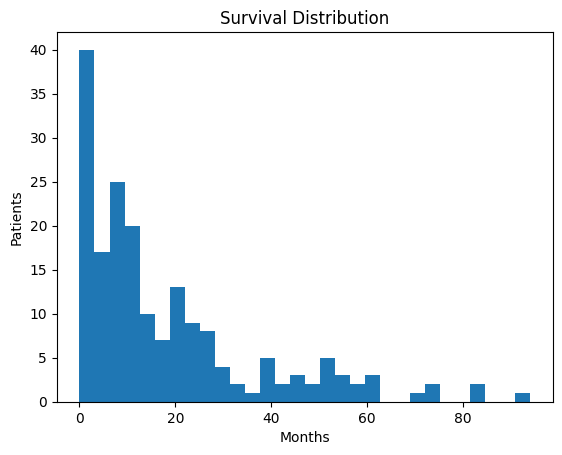

In [51]:
# Survival Distribution

plt.hist(df['OS_MONTHS'], bins=30)
plt.title("Survival Distribution")
plt.xlabel("Months")
plt.ylabel("Patients")
plt.show()

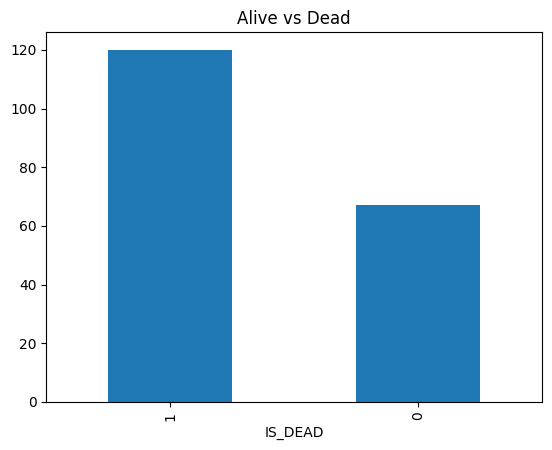

In [52]:
# Alive vs Dead

df['IS_DEAD'].value_counts().plot(kind='bar')
plt.title("Alive vs Dead")
plt.show()

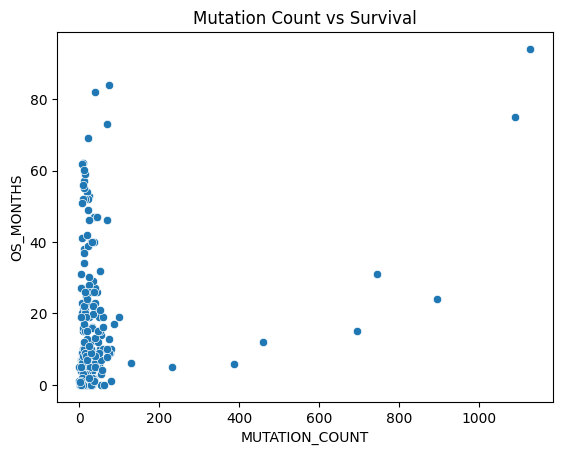

In [53]:
# Mutation Count vs Survival

sns.scatterplot(x='MUTATION_COUNT', y='OS_MONTHS', data=df)
plt.title("Mutation Count vs Survival")
plt.show()

Mutation-Level Analysis

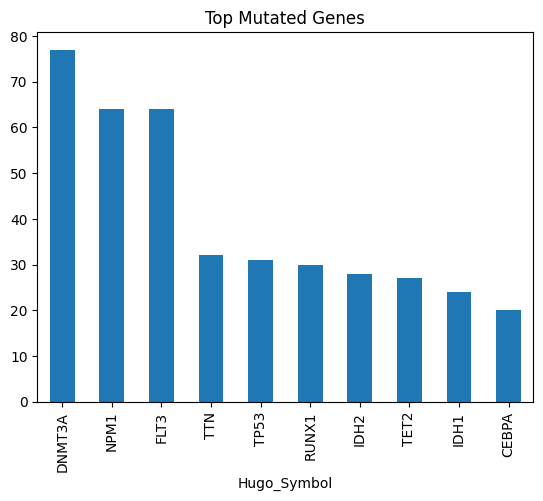

In [55]:
# Top Genes

top_genes = mutation['Hugo_Symbol'].value_counts().head(10)

top_genes.plot(kind='bar')
plt.title("Top Mutated Genes")
plt.show()

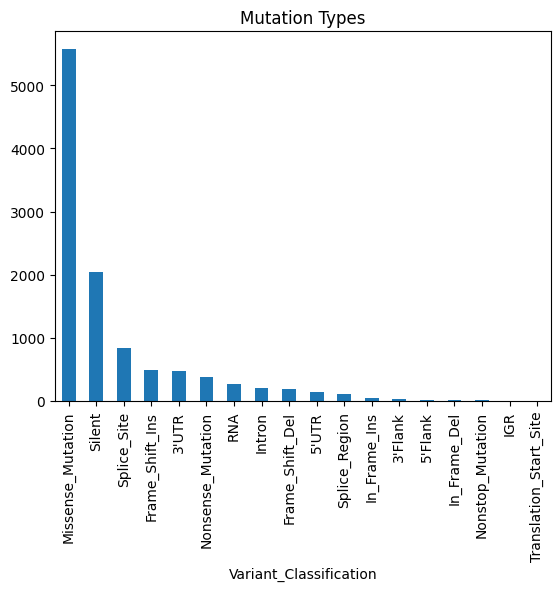

In [56]:
# Mutation Types

mutation['Variant_Classification'].value_counts().plot(kind='bar')
plt.title("Mutation Types")
plt.show()

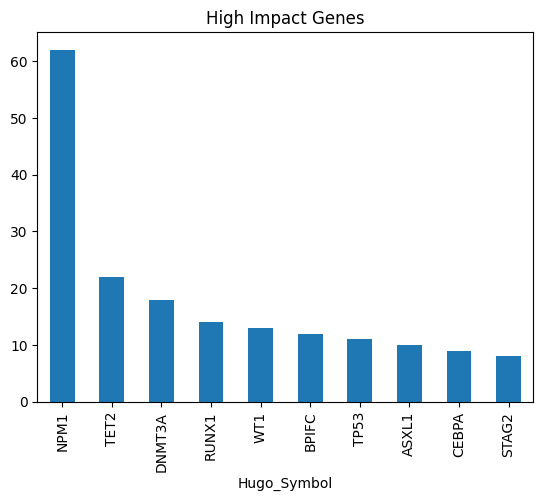

In [57]:
# High Impact Genes

high_impact['Hugo_Symbol'].value_counts().head(10).plot(kind='bar')
plt.title("High Impact Genes")
plt.show()

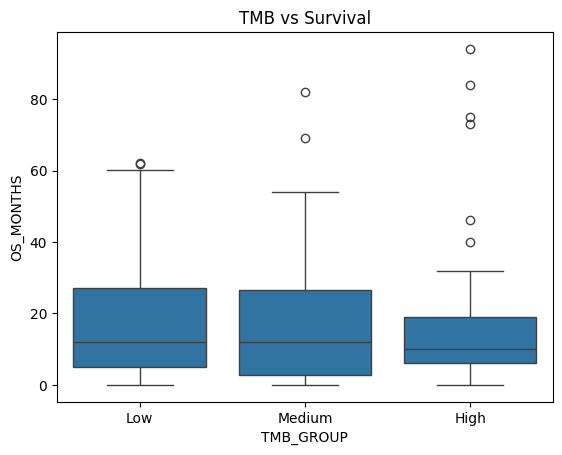

In [58]:
# TMB Group Analysis

df['TMB_GROUP'] = pd.qcut(df['TMB_NONSYNONYMOUS'], q=3, labels=['Low','Medium','High'])

sns.boxplot(x='TMB_GROUP', y='OS_MONTHS', data=df)
plt.title("TMB vs Survival")
plt.show()

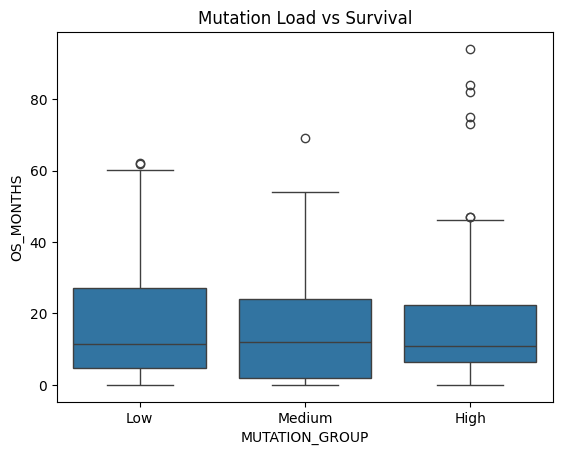

In [59]:
# Mutation Load vs Survival

df['MUTATION_GROUP'] = pd.qcut(df['MUTATION_COUNT'], q=3, labels=['Low','Medium','High'])

sns.boxplot(x='MUTATION_GROUP', y='OS_MONTHS', data=df)
plt.title("Mutation Load vs Survival")
plt.show()

 Correlation Analysis

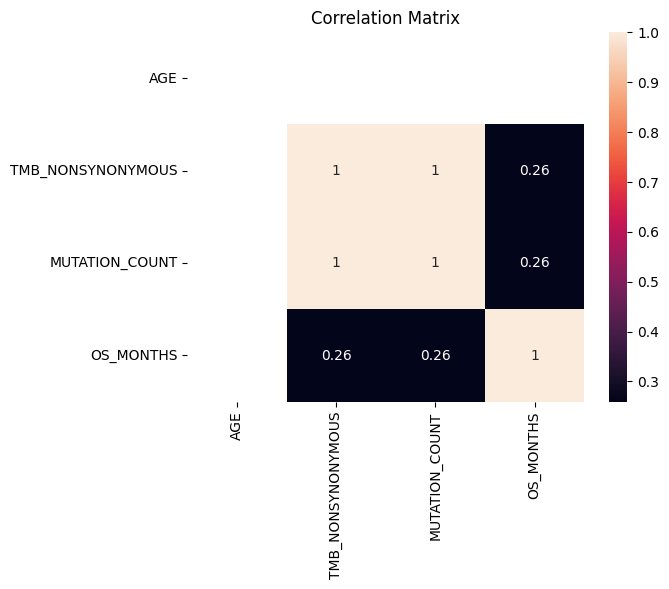

In [61]:
sns.heatmap(df[['AGE','TMB_NONSYNONYMOUS','MUTATION_COUNT','OS_MONTHS']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

Statistical Testing

In [62]:
from scipy.stats import ttest_ind

group1 = df[df['TMB_GROUP'] == 'High']['OS_MONTHS']
group2 = df[df['TMB_GROUP'] == 'Low']['OS_MONTHS']

print(ttest_ind(group1, group2, nan_policy='omit'))

TtestResult(statistic=np.float64(-0.7287429863434631), pvalue=np.float64(0.4675670100323477), df=np.float64(121.0))
